# Accelerated Non-Local Means Denoising as Neural Network Post-Processing

## Phase 1 — CPU Baseline, Bottleneck Analysis, and GPU Design

This notebook isolates the **Non-Local Means (NLM)** stage so that its correctness,
computational cost, and GPU parallelization strategy can be studied independently.

The neural-network denoiser is not implemented in this phase. In the final system,
the optimized NLM kernel can be inserted after a pretrained denoising model such as
DnCNN or FFDNet as a refinement step.

### Notebook objectives

1. Implement a readable CPU NLM reference.
2. Verify that NLM improves denoising quality.
3. Compare NLM with simple local filters.
4. Measure whether NLM is the bottleneck of the image-processing pipeline.
5. Analyze how runtime scales with image size.
6. Design GPU V1, V2, and V3.
7. Define a fair correctness and performance-evaluation protocol.


## Notebook Structure

1. Problem and scope  
2. Environment and reproducibility  
3. Experimental configuration  
4. NLM formulation and CPU baseline  
5. Quality baselines  
6. Workload and complexity analysis  
7. Bottleneck profiling  
8. Scalability analysis  
9. GPU design  
10. Benchmarking and correctness protocol  
11. Neural-network integration plan


# 1. Problem and Scope

Digital images are frequently degraded by sensor noise, low-light conditions,
or transmission errors. A denoising algorithm should suppress noise while
preserving edges, textures, and small structures.

Non-Local Means estimates each output pixel from candidate pixels whose
surrounding patches are similar to the reference patch. This generally preserves
structure better than a simple local average, but repeated patch comparisons make
the method computationally expensive.

## Important complexity distinction

For an image of height \(H\) and width \(W\), patch size \(P\times P\), and
search window \(S\times S\), the practical local-search implementation used in
this notebook has approximate complexity

\[
O(HW\,S^2P^2).
\]

When \(P\) and \(S\) are fixed, runtime is approximately linear in the number
of pixels \(HW\). Therefore, doubling both image dimensions produces four times
as many output pixels and is expected to increase CPU runtime by roughly \(4\times\).

A full-image search is different: if every patch is compared with every other
patch, the number of patch pairs is quadratic in the number of pixels.
This notebook uses the practical **local search-window variant**.


# 2. Environment and Reproducibility

The following cell records package versions, the random seed, and the available
GPU. These details should be included when reporting runtime because Google Colab
may assign different GPU models between sessions.


In [1]:
import platform
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import skimage

from scipy.ndimage import gaussian_filter, median_filter
from skimage import data, transform
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("scikit-image:", skimage.__version__)
print("Random seed:", RANDOM_SEED)

try:
    gpu_info = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    print("GPU:", gpu_info)
except (FileNotFoundError, subprocess.CalledProcessError):
    print("GPU: not available in the current runtime")


Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 2.0.2
SciPy: 1.16.3
scikit-image: 0.25.2
Random seed: 42
GPU: Tesla T4, 15360 MiB


# 3. Experimental Configuration

All parameters are defined in one cell so that subsequent experiments use the
same image, noise realization, patch size, search window, and filtering strength.

Both patch size and search-window size are odd so that they have a well-defined
center. Candidate patches have the same size as the reference patch. Reflect
padding is used near image boundaries.


In [2]:
IMAGE_SIZE = 64
NOISE_SIGMA = 0.08
PATCH_SIZE = 3
SEARCH_WINDOW_SIZE = 7
FILTER_H = 0.12

if PATCH_SIZE % 2 == 0:
    raise ValueError("PATCH_SIZE must be odd.")

if SEARCH_WINDOW_SIZE % 2 == 0:
    raise ValueError("SEARCH_WINDOW_SIZE must be odd.")

if SEARCH_WINDOW_SIZE < PATCH_SIZE:
    raise ValueError("The search window must be at least as large as the patch.")

PATCH_RADIUS = PATCH_SIZE // 2
SEARCH_RADIUS = SEARCH_WINDOW_SIZE // 2
PADDING_RADIUS = PATCH_RADIUS + SEARCH_RADIUS

clean_image = data.camera().astype(np.float32) / 255.0
clean_image = transform.resize(
    clean_image,
    (IMAGE_SIZE, IMAGE_SIZE),
    anti_aliasing=True,
).astype(np.float32)

gaussian_noise = np.random.normal(
    loc=0.0,
    scale=NOISE_SIGMA,
    size=clean_image.shape,
).astype(np.float32)

noisy_image = np.clip(
    clean_image + gaussian_noise,
    0.0,
    1.0,
).astype(np.float32)

print(f"Image size:          {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Patch size:          {PATCH_SIZE} × {PATCH_SIZE}")
print(f"Search window:       {SEARCH_WINDOW_SIZE} × {SEARCH_WINDOW_SIZE}")
print(f"Patch radius:        {PATCH_RADIUS}")
print(f"Search radius:       {SEARCH_RADIUS}")
print(f"Required padding:    {PADDING_RADIUS}")
print(f"Noise sigma:         {NOISE_SIGMA}")
print(f"Filtering parameter: {FILTER_H}")


Image size:          64 × 64
Patch size:          3 × 3
Search window:       7 × 7
Patch radius:        1
Search radius:       3
Required padding:    4
Noise sigma:         0.08
Filtering parameter: 0.12


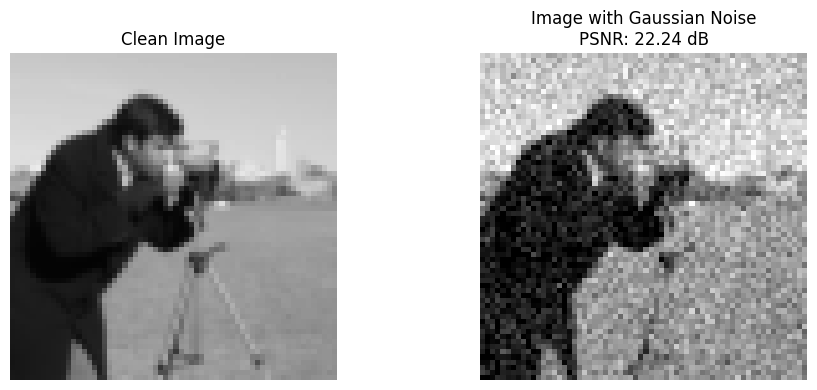

In [3]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clean_image, cmap="gray", vmin=0, vmax=1)
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_image, cmap="gray", vmin=0, vmax=1)
plt.title(
    "Image with Gaussian Noise\n"
    f"PSNR: {peak_signal_noise_ratio(clean_image, noisy_image, data_range=1.0):.2f} dB"
)
plt.axis("off")

plt.tight_layout()
plt.show()


# 4. NLM Formulation and CPU Baseline

For an output pixel \(x\), let \(P_x\) be its reference patch. Candidate patch
centers \(y\) are scanned inside the search window.

The patch distance is

$$
d(P_x,P_y)
=
\frac{1}{|P|}
\sum_{k\in P}
\left(P_x(k)-P_y(k)\right)^2.
$$

The similarity weight is

$$
w(x,y)
=
\exp\left(-\frac{d(P_x,P_y)}{h^2}\right).
$$

The output pixel is

$$
\hat I(x)
=
\frac{\sum_y w(x,y)I(y)}
{\sum_y w(x,y)}.
$$

The patch is used only to determine similarity. The final weighted average uses
the **center pixel** I(y) of each candidate patch.

Because the center of the search window is also a candidate position, the
reference patch is compared with itself. Its distance is zero and its weight is
therefore one.


In [4]:
def nlm_cpu_naive(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12
) -> np.ndarray:
    """
    Naive CPU implementation of Non-Local Means for a grayscale image.

    Parameters
    ----------
    image:
        Grayscale float32 image with values in [0, 1].
    patch_size:
        Odd patch size, for example 3 or 5.
    search_window_size:
        Odd search-window size, for example 7 or 11.
    h:
        Filtering parameter controlling how quickly weights decrease.

    Returns
    -------
    Denoised image with the same shape as the input.
    """
    if image.ndim != 2:
        raise ValueError("This demo supports grayscale images only.")

    if patch_size % 2 == 0 or search_window_size % 2 == 0:
        raise ValueError("Patch size and search-window size must be odd.")

    if search_window_size < patch_size:
        raise ValueError("Search window must be at least as large as the patch.")

    if h <= 0:
        raise ValueError("h must be greater than zero.")

    height, width = image.shape
    patch_radius = patch_size // 2
    search_radius = search_window_size // 2

    # Padding allows patches near image boundaries to be extracted safely.
    pad_size = patch_radius + search_radius
    padded = np.pad(
        image,
        pad_width=pad_size,
        mode="reflect"
    )

    output = np.zeros_like(image, dtype=np.float32)
    h_squared = h * h
    epsilon = 1e-12

    for row in range(height):
        for col in range(width):
            # Position of the current pixel in the padded image.
            center_row = row + pad_size
            center_col = col + pad_size

            # Reference patch around the current output pixel.
            reference_patch = padded[
                center_row - patch_radius:center_row + patch_radius + 1,
                center_col - patch_radius:center_col + patch_radius + 1
            ]

            weighted_sum = 0.0
            weight_sum = 0.0

            # Search candidate patch centers inside the search window.
            for offset_row in range(-search_radius, search_radius + 1):
                for offset_col in range(-search_radius, search_radius + 1):
                    candidate_row = center_row + offset_row
                    candidate_col = center_col + offset_col

                    candidate_patch = padded[
                        candidate_row - patch_radius:
                        candidate_row + patch_radius + 1,
                        candidate_col - patch_radius:
                        candidate_col + patch_radius + 1
                    ]

                    # Mean squared difference between two patches.
                    difference = reference_patch - candidate_patch
                    distance = np.mean(difference * difference)

                    # Similarity weight.
                    weight = np.exp(-distance / h_squared)

                    # Center pixel corresponding to this candidate patch.
                    candidate_center_pixel = padded[
                        candidate_row,
                        candidate_col
                    ]

                    weighted_sum += weight * candidate_center_pixel
                    weight_sum += weight

            output[row, col] = weighted_sum / (weight_sum + epsilon)

    return np.clip(output, 0.0, 1.0).astype(np.float32)


In [5]:
start_time = time.perf_counter()

denoised_cpu = nlm_cpu_naive(
    noisy_image,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
)

cpu_runtime_seconds = time.perf_counter() - start_time

noisy_psnr = peak_signal_noise_ratio(
    clean_image,
    noisy_image,
    data_range=1.0,
)
denoised_psnr = peak_signal_noise_ratio(
    clean_image,
    denoised_cpu,
    data_range=1.0,
)
denoised_ssim = structural_similarity(
    clean_image,
    denoised_cpu,
    data_range=1.0,
)

print("CPU NLM completed.")
print(f"Runtime:          {cpu_runtime_seconds:.4f} seconds")
print(f"Noisy PSNR:       {noisy_psnr:.2f} dB")
print(f"Denoised PSNR:    {denoised_psnr:.2f} dB")
print(f"Denoised SSIM:    {denoised_ssim:.4f}")
print(f"PSNR improvement: {denoised_psnr - noisy_psnr:.2f} dB")


CPU NLM completed.
Runtime:          5.7450 seconds
Noisy PSNR:       22.24 dB
Denoised PSNR:    29.71 dB
Denoised SSIM:    0.8444
PSNR improvement: 7.47 dB


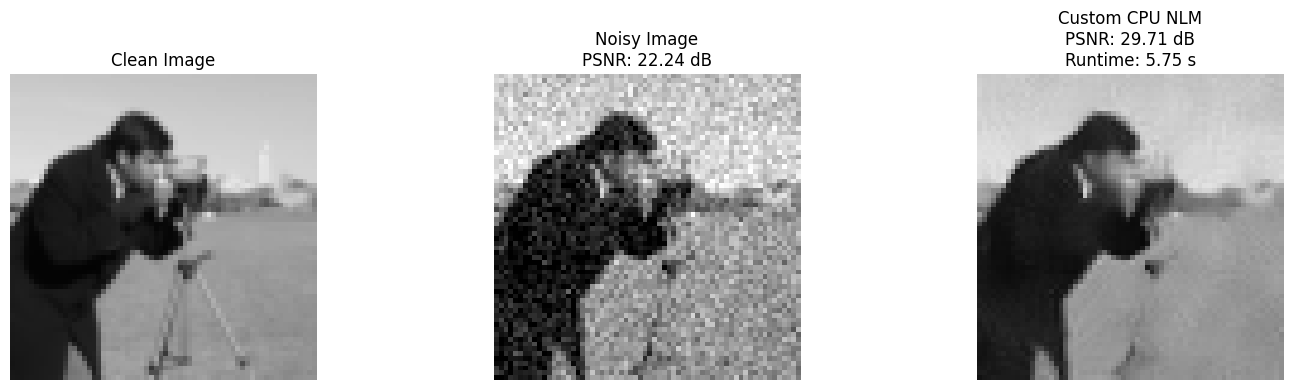

In [6]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(clean_image, cmap="gray", vmin=0, vmax=1)
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap="gray", vmin=0, vmax=1)
plt.title(f"Noisy Image\nPSNR: {noisy_psnr:.2f} dB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised_cpu, cmap="gray", vmin=0, vmax=1)
plt.title(
    "Custom CPU NLM\n"
    f"PSNR: {denoised_psnr:.2f} dB\n"
    f"Runtime: {cpu_runtime_seconds:.2f} s"
)
plt.axis("off")

plt.tight_layout()
plt.show()


# 5. Quality Baselines

Gaussian and Median filters are included as simple local baselines.

- **Gaussian filter:** fast local smoothing, but may blur edges and textures.
- **Median filter:** useful for impulse-like noise and often preserves edges better
  than a local mean.
- **NLM:** compares patches and is expected to preserve repeated structures better,
  but has much higher computational cost.

These filters are used to compare denoising quality. The main GPU speedup baseline
remains the custom CPU NLM implementation.


In [7]:
def timed_filter(filter_function):
    start = time.perf_counter()
    output = filter_function()
    runtime = time.perf_counter() - start
    return np.clip(output, 0.0, 1.0).astype(np.float32), runtime


gaussian_output, gaussian_runtime = timed_filter(
    lambda: gaussian_filter(
        noisy_image,
        sigma=1.0,
        mode="reflect",
    )
)

median_output, median_runtime = timed_filter(
    lambda: median_filter(
        noisy_image,
        size=3,
        mode="reflect",
    )
)

quality_outputs = {
    "Noisy image": (noisy_image, 0.0),
    "Gaussian filter": (gaussian_output, gaussian_runtime),
    "Median filter": (median_output, median_runtime),
    "Custom CPU NLM": (denoised_cpu, cpu_runtime_seconds),
}

quality_rows = []

for method_name, (method_output, method_runtime) in quality_outputs.items():
    quality_rows.append(
        {
            "Method": method_name,
            "Runtime (s)": method_runtime,
            "PSNR (dB)": peak_signal_noise_ratio(
                clean_image,
                method_output,
                data_range=1.0,
            ),
            "SSIM": structural_similarity(
                clean_image,
                method_output,
                data_range=1.0,
            ),
        }
    )

quality_table = pd.DataFrame(quality_rows)
display(quality_table)


,Method,Runtime (s),PSNR (dB),SSIM
0,Noisy image,0.000000,22.244869,0.496953
1,Gaussian filter,0.000380,26.815350,0.785026
2,Median filter,0.001281,26.701070,0.693850
3,Custom CPU NLM,5.745019,29.712385,0.844359


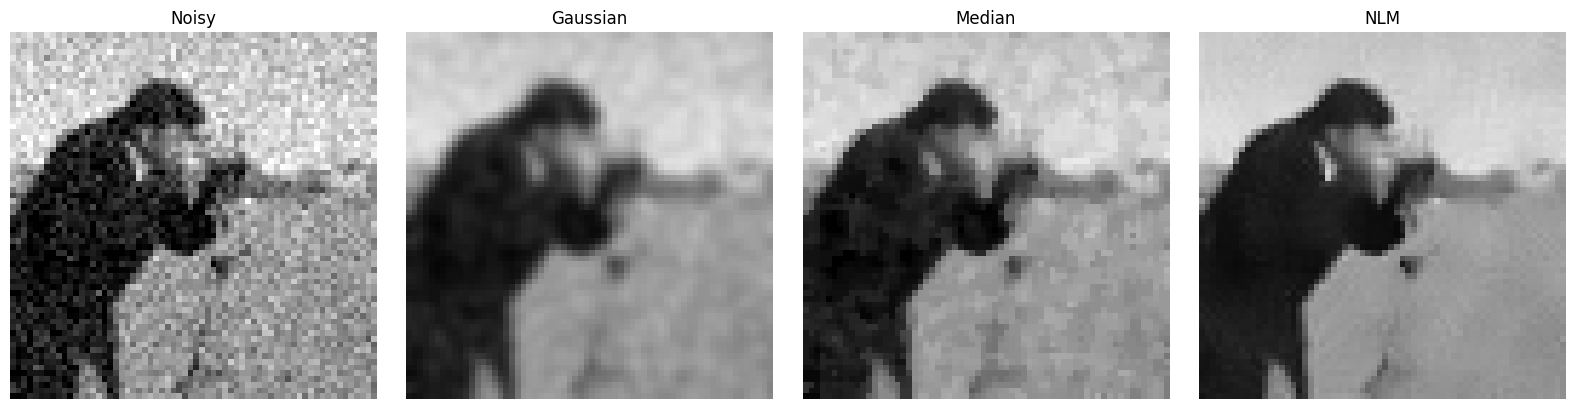

In [8]:
plt.figure(figsize=(16, 4))

comparison_images = [
    ("Noisy", noisy_image),
    ("Gaussian", gaussian_output),
    ("Median", median_output),
    ("NLM", denoised_cpu),
]

for index, (name, image) in enumerate(comparison_images, start=1):
    plt.subplot(1, 4, index)
    plt.imshow(image, cmap="gray", vmin=0, vmax=1)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


# 6. Workload and Complexity Analysis

For a fixed local search window, each output pixel performs

$$
S^2
$$

candidate-patch comparisons, and every comparison processes

$$
P^2
$$

patch elements. The approximate number of squared-difference operations is

$$
HW\,S^2P^2.
$$

This operation count excludes exponential weight computation, weighted
accumulation, boundary handling, and Python-loop overhead.


In [9]:
def estimate_nlm_workload(
    image_shape,
    patch_size,
    search_window_size,
):
    height, width = image_shape

    output_pixels = height * width
    candidate_patches_per_pixel = search_window_size ** 2
    elements_per_patch = patch_size ** 2

    patch_comparisons = (
        output_pixels
        * candidate_patches_per_pixel
    )

    pixel_difference_operations = (
        patch_comparisons
        * elements_per_patch
    )

    return {
        "output_pixels": output_pixels,
        "candidate_patches_per_pixel": candidate_patches_per_pixel,
        "elements_per_patch": elements_per_patch,
        "patch_comparisons": patch_comparisons,
        "pixel_difference_operations": pixel_difference_operations,
    }


workload = estimate_nlm_workload(
    noisy_image.shape,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
)

for key, value in workload.items():
    print(f"{key:<34} {value:,}")


output_pixels                      4,096
candidate_patches_per_pixel        49
elements_per_patch                 9
patch_comparisons                  200,704
pixel_difference_operations        1,806,336


For the default $64\times64$ image, $3\times3$ patch, and $7\times7$ search window:

$$
64\cdot64\cdot7\cdot7 = 200{,}704
$$

patch comparisons are required, corresponding to

$$
200{,}704\cdot9 = 1{,}806{,}336
$$

pixel-level squared-difference operations.

# 7. Bottleneck Profiling

Profiling is performed at two levels:

1. **Pipeline-level profiling:** determines whether NLM dominates the complete
   image-processing pipeline.
2. **Internal NLM profiling:** estimates which operations inside the NLM loop
   consume the most time.

Pipeline-level profiling should be presented first because it justifies why NLM,
rather than image loading or metric computation, is the GPU target.


In [10]:
def profile_cpu_pipeline(
    image_size=64,
    noise_sigma=0.08,
    patch_size=3,
    search_window_size=7,
    h=0.12,
    seed=42,
):
    timings = {}
    rng = np.random.default_rng(seed)

    start = time.perf_counter()
    clean = data.camera().astype(np.float32) / 255.0
    clean = transform.resize(
        clean,
        (image_size, image_size),
        anti_aliasing=True,
    ).astype(np.float32)
    timings["Image preprocessing"] = time.perf_counter() - start

    start = time.perf_counter()
    noise = rng.normal(
        0.0,
        noise_sigma,
        size=clean.shape,
    ).astype(np.float32)
    noisy = np.clip(clean + noise, 0.0, 1.0)
    timings["Noise generation"] = time.perf_counter() - start

    start = time.perf_counter()
    denoised = nlm_cpu_naive(
        noisy,
        patch_size=patch_size,
        search_window_size=search_window_size,
        h=h,
    )
    timings["NLM denoising"] = time.perf_counter() - start

    start = time.perf_counter()
    _ = peak_signal_noise_ratio(
        clean,
        denoised,
        data_range=1.0,
    )
    _ = structural_similarity(
        clean,
        denoised,
        data_range=1.0,
    )
    timings["Metric computation"] = time.perf_counter() - start

    total_runtime = sum(timings.values())

    table = pd.DataFrame(
        {
            "Stage": list(timings.keys()),
            "Runtime (s)": list(timings.values()),
        }
    )
    table["Percentage (%)"] = (
        table["Runtime (s)"] / total_runtime * 100.0
    )

    return table, total_runtime


pipeline_profile, pipeline_total = profile_cpu_pipeline(
    image_size=IMAGE_SIZE,
    noise_sigma=NOISE_SIGMA,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
    seed=RANDOM_SEED,
)

display(pipeline_profile)
print(f"Total measured pipeline runtime: {pipeline_total:.4f} s")


,Stage,Runtime (s),Percentage (%)
0,Image preprocessing,0.022011,0.343529
1,Noise generation,0.000147,0.002290
2,NLM denoising,6.381937,99.604872
3,Metric computation,0.003159,0.049308


Total measured pipeline runtime: 6.4073 s


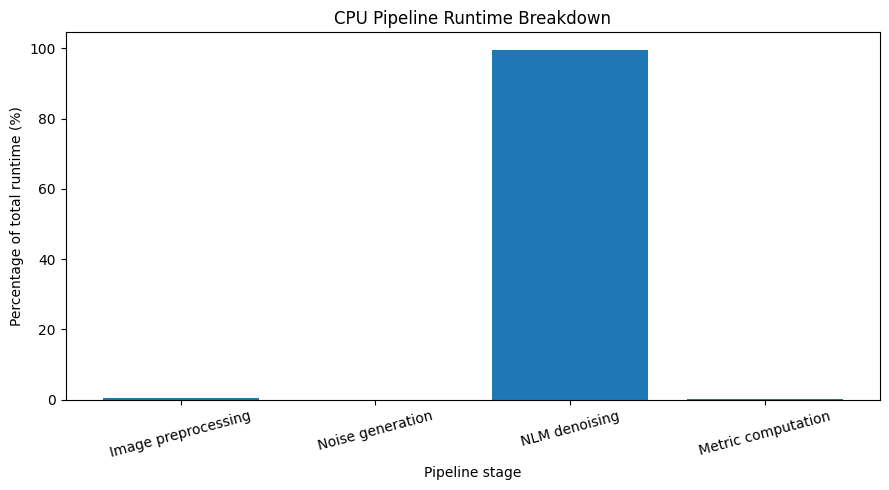

NLM share of pipeline runtime: 99.60%


In [11]:
plt.figure(figsize=(9, 5))
plt.bar(
    pipeline_profile["Stage"],
    pipeline_profile["Percentage (%)"],
)
plt.xlabel("Pipeline stage")
plt.ylabel("Percentage of total runtime (%)")
plt.title("CPU Pipeline Runtime Breakdown")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

nlm_pipeline_share = pipeline_profile.loc[
    pipeline_profile["Stage"] == "NLM denoising",
    "Percentage (%)",
].iloc[0]

print(f"NLM share of pipeline runtime: {nlm_pipeline_share:.2f}%")


## 7.1 Pipeline-Level Conclusion

Use the measured percentage rather than assuming that NLM occupies a fixed
fraction of runtime. If NLM dominates the pipeline, this experiment provides
direct evidence that it is the correct target for GPU acceleration.


## 7.2 Instrumented Internal NLM Profiling

The following diagnostic implementation times patch distance, exponential weight,
and weighted accumulation separately.

**Measurement caution:** calling `time.perf_counter()` inside the innermost loop
adds instrumentation overhead. Therefore, this section is useful for locating the
dominant operation, but its component percentages should not be treated as exact
production timings. Kernel-level profiling should later use CUDA Events and tools
such as Nsight Compute.


In [12]:
def nlm_cpu_profiled(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12
):
    """
    Naive CPU NLM with coarse-grained profiling.

    Returns
    -------
    output:
        Denoised image.
    timings:
        Dictionary containing time spent in:
        - patch_distance
        - weight_computation
        - weighted_accumulation
        - total
    """
    if image.ndim != 2:
        raise ValueError("Only grayscale images are supported.")

    if patch_size % 2 == 0:
        raise ValueError("patch_size must be odd.")

    if search_window_size % 2 == 0:
        raise ValueError(
            "search_window_size must be odd."
        )

    if search_window_size < patch_size:
        raise ValueError(
            "Search window must be at least as large "
            "as the patch."
        )

    if h <= 0:
        raise ValueError("h must be positive.")

    height, width = image.shape

    patch_radius = patch_size // 2
    search_radius = search_window_size // 2

    pad_size = patch_radius + search_radius

    padded = np.pad(
        image,
        pad_width=pad_size,
        mode="reflect"
    )

    output = np.zeros_like(
        image,
        dtype=np.float32
    )

    h_squared = h * h
    epsilon = 1e-12

    patch_distance_time = 0.0
    weight_time = 0.0
    accumulation_time = 0.0

    total_start = time.perf_counter()

    for row in range(height):
        for col in range(width):
            center_row = row + pad_size
            center_col = col + pad_size

            reference_patch = padded[
                center_row - patch_radius:
                center_row + patch_radius + 1,
                center_col - patch_radius:
                center_col + patch_radius + 1
            ]

            weighted_sum = 0.0
            weight_sum = 0.0

            for offset_row in range(
                -search_radius,
                search_radius + 1
            ):
                for offset_col in range(
                    -search_radius,
                    search_radius + 1
                ):
                    candidate_row = (
                        center_row + offset_row
                    )

                    candidate_col = (
                        center_col + offset_col
                    )

                    candidate_patch = padded[
                        candidate_row - patch_radius:
                        candidate_row + patch_radius + 1,
                        candidate_col - patch_radius:
                        candidate_col + patch_radius + 1
                    ]

                    # 1. Patch distance / SSD
                    t0 = time.perf_counter()

                    difference = (
                        reference_patch
                        - candidate_patch
                    )

                    distance = np.mean(
                        difference * difference
                    )

                    t1 = time.perf_counter()

                    patch_distance_time += t1 - t0

                    # 2. Weight computation
                    t0 = time.perf_counter()

                    weight = np.exp(
                        -distance / h_squared
                    )

                    t1 = time.perf_counter()

                    weight_time += t1 - t0

                    # 3. Weighted accumulation
                    t0 = time.perf_counter()

                    candidate_center = padded[
                        candidate_row,
                        candidate_col
                    ]

                    weighted_sum += (
                        weight * candidate_center
                    )

                    weight_sum += weight

                    t1 = time.perf_counter()

                    accumulation_time += t1 - t0

            output[row, col] = (
                weighted_sum
                / (weight_sum + epsilon)
            )

    total_end = time.perf_counter()

    timings = {
        "patch_distance":
            patch_distance_time,
        "weight_computation":
            weight_time,
        "weighted_accumulation":
            accumulation_time,
        "total":
            total_end - total_start
    }

    return (
        np.clip(
            output,
            0.0,
            1.0
        ).astype(np.float32),
        timings
    )


In [13]:
profiled_output, profile_timings = nlm_cpu_profiled(
    noisy_image,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
)

profile_total = profile_timings["total"]

accounted_time = sum(
    profile_timings[name]
    for name in [
        "patch_distance",
        "weight_computation",
        "weighted_accumulation",
    ]
)

other_time = max(profile_total - accounted_time, 0.0)

internal_profile = pd.DataFrame(
    [
        {
            "Stage": "Patch distance",
            "Runtime (s)": profile_timings["patch_distance"],
        },
        {
            "Stage": "Weight computation",
            "Runtime (s)": profile_timings["weight_computation"],
        },
        {
            "Stage": "Weighted accumulation",
            "Runtime (s)": profile_timings["weighted_accumulation"],
        },
        {
            "Stage": "Other / Python-loop overhead",
            "Runtime (s)": other_time,
        },
    ]
)

internal_profile["Percentage (%)"] = (
    internal_profile["Runtime (s)"] / profile_total * 100.0
)

display(internal_profile)
print(f"Instrumented total runtime: {profile_total:.4f} s")


,Stage,Runtime (s),Percentage (%)
0,Patch distance,5.691320,79.143100
1,Weight computation,0.720512,10.019384
2,Weighted accumulation,0.279572,3.887709
3,Other / Python-loop overhead,0.499773,6.949806


Instrumented total runtime: 7.1912 s


In [14]:
max_absolute_difference = np.max(
    np.abs(profiled_output - denoised_cpu)
)

print(f"Maximum CPU-output difference: {max_absolute_difference:.8f}")

assert np.allclose(
    profiled_output,
    denoised_cpu,
    atol=1e-6,
), "The profiled implementation does not match the CPU reference."

print("Correctness check passed.")


Maximum CPU-output difference: 0.00000000
Correctness check passed.


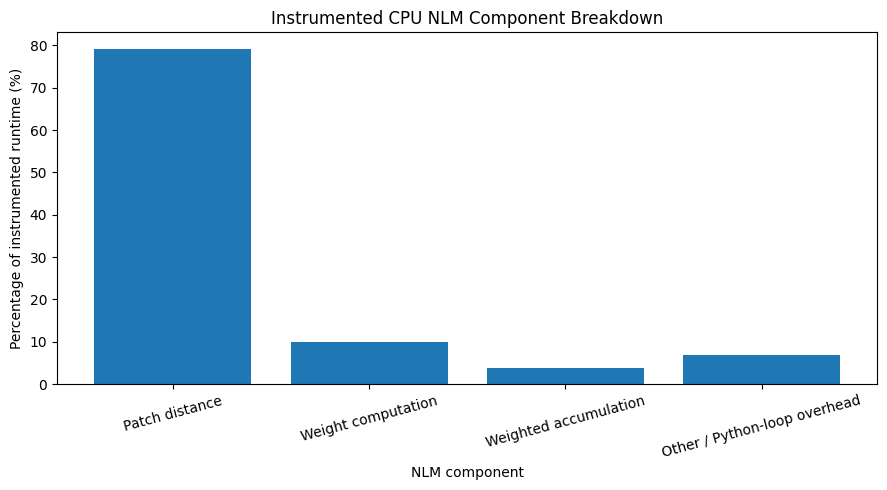

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(
    internal_profile["Stage"],
    internal_profile["Percentage (%)"],
)
plt.xlabel("NLM component")
plt.ylabel("Percentage of instrumented runtime (%)")
plt.title("Instrumented CPU NLM Component Breakdown")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7.3 Bottleneck Interpretation

The target is not only the exponential function or the final weighted average.
The dominant computational region is the repeated **patch-comparison loop**:

- candidate-patch extraction;
- squared pixel differences;
- reduction into one patch distance;
- repeated execution for every candidate and output pixel.

This region exposes parallelism across output pixels, candidate patches, and patch
elements.


# 8. Scalability Analysis

This experiment measures how CPU runtime changes as image dimensions increase
while patch size and search-window size remain fixed.

When both image dimensions double, the number of pixels increases by four.
For fixed \(P\) and \(S\), the expected runtime ratio is therefore approximately
$4\times$, although cache behavior, Python overhead, and memory effects may
produce deviations.

The $128\times128\times128$ case may take noticeably longer because this is a naive
Python implementation.


In [16]:
SCALABILITY_SIZES = [32, 64, 128]
scalability_rows = []

for size in SCALABILITY_SIZES:
    rng = np.random.default_rng(RANDOM_SEED)

    clean = data.camera().astype(np.float32) / 255.0
    clean = transform.resize(
        clean,
        (size, size),
        anti_aliasing=True,
    ).astype(np.float32)

    noise = rng.normal(
        0.0,
        NOISE_SIGMA,
        size=clean.shape,
    ).astype(np.float32)

    noisy = np.clip(clean + noise, 0.0, 1.0)

    start = time.perf_counter()

    _ = nlm_cpu_naive(
        noisy,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
    )

    runtime = time.perf_counter() - start

    scalability_rows.append(
        {
            "Image size": f"{size} × {size}",
            "Width": size,
            "Pixels": size * size,
            "Runtime (s)": runtime,
            "Time per pixel (ms)": runtime / (size * size) * 1000.0,
        }
    )

scalability_table = pd.DataFrame(scalability_rows)
scalability_table["Runtime ratio vs previous"] = (
    scalability_table["Runtime (s)"]
    / scalability_table["Runtime (s)"].shift(1)
)
scalability_table["Pixel ratio vs previous"] = (
    scalability_table["Pixels"]
    / scalability_table["Pixels"].shift(1)
)

display(scalability_table)


,Image size,Width,Pixels,Runtime (s),Time per pixel (ms),Runtime ratio vs previous,Pixel ratio vs previous
0,32 × 32,32,1024,0.644766,0.629654,NaN,NaN
1,64 × 64,64,4096,3.945217,0.963188,6.118834,4.0
2,128 × 128,128,16384,11.022507,0.672760,2.793891,4.0


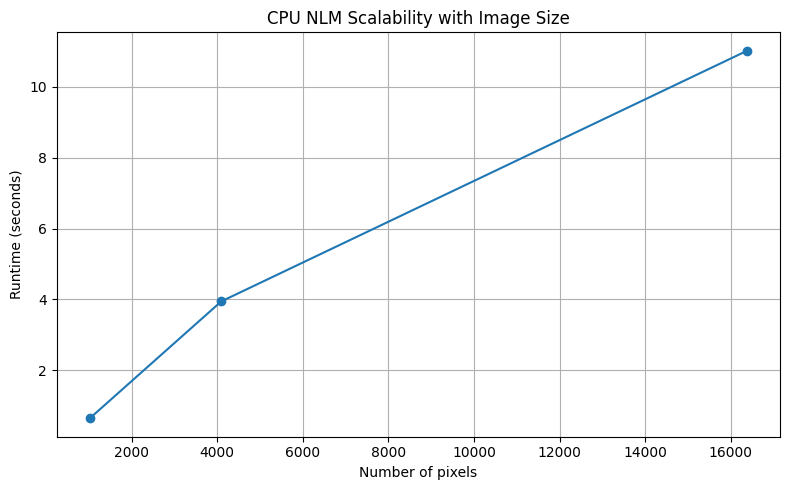

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    scalability_table["Pixels"],
    scalability_table["Runtime (s)"],
    marker="o",
)
plt.xlabel("Number of pixels")
plt.ylabel("Runtime (seconds)")
plt.title("CPU NLM Scalability with Image Size")
plt.grid(True)
plt.tight_layout()
plt.show()


# 9. GPU Design

The GPU implementation is developed incrementally so that every optimization can
be validated against the same CPU reference.

- **GPU V1:** one CUDA thread per output pixel;
- **GPU V2:** shared-memory tile plus halo;
- **GPU V3:** arithmetic, reduction, and kernel-level optimizations.


## 9.1 GPU V1 — One Thread per Output Pixel

A two-dimensional CUDA grid maps one thread to one output pixel.

Each thread:

1. locates its reference patch;
2. scans all candidate centers in the search window;
3. computes patch distances and weights;
4. accumulates candidate center pixels;
5. writes one output value.

Example configuration:

```text
Block size: 16 × 16 threads
Grid size:
ceil(width / 16) × ceil(height / 16)
```

This design is simple and provides enough parallel work because an image contains
many independent output pixels. The limitation is repeated global-memory access
to heavily overlapping patches.


### GPU V1 Pseudocode

```cpp
kernel nlm_gpu_v1(input, output, width, height, patch_radius, search_radius, h)
{
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height)
        return;

    float weighted_sum = 0.0f;
    float weight_sum = 0.0f;

    for each candidate center in the search window
    {
        float distance = 0.0f;

        for each element in the patch
        {
            float difference =
                reference_patch_element
                - candidate_patch_element;

            distance += difference * difference;
        }

        distance /= patch_area;

        float weight = expf(-distance / (h * h));

        weighted_sum += weight * candidate_center_pixel;
        weight_sum += weight;
    }

    output[y * width + x] = weighted_sum / weight_sum;
}
```


In [18]:
# !pip install -q cupy-cuda12x

In [19]:
import subprocess
import time

import cupy as cp
import numpy as np
import pandas as pd

print("CuPy version:", cp.__version__)

device = cp.cuda.Device()
device.use()

device_properties = cp.cuda.runtime.getDeviceProperties(
    device.id
)

gpu_name = device_properties["name"]

if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode("utf-8")

print("GPU device ID:", device.id)
print("GPU name:", gpu_name)
print(
    "Global memory:",
    f"{device_properties['totalGlobalMem'] / 1024**3:.2f} GB",
)

try:
    print(
        subprocess.run(
            ["nvidia-smi"],
            capture_output=True,
            text=True,
            check=True,
        ).stdout
    )
except Exception as error:
    print("Could not execute nvidia-smi:", error)

CuPy version: 14.0.1
GPU device ID: 0
GPU name: Tesla T4
Global memory: 14.56 GB
Tue Jul 28 08:30:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             27W /   70W |     105MiB /  15360MiB |      4%      Default |
|                                         |                

In [20]:
import subprocess
import sys

print("Python:", sys.executable)

result = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True,
)

print(result.stdout)
print(result.stderr)

Python: /usr/bin/python3
Tue Jul 28 08:30:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             28W /   70W |     105MiB /  15360MiB |      1%      Default |
|                                         |                        |                  N/A |
+----------------------

In [21]:
nlm_gpu_v1_kernel_code = r'''
extern "C" __global__
void nlm_gpu_v1(
    const float* __restrict__ padded_input,
    float* __restrict__ output,
    const int width,
    const int height,
    const int padded_width,
    const int patch_radius,
    const int search_radius,
    const float h_squared
)
{
    // One CUDA thread handles one output pixel.
    const int output_x =
        blockIdx.x * blockDim.x + threadIdx.x;

    const int output_y =
        blockIdx.y * blockDim.y + threadIdx.y;

    if (output_x >= width || output_y >= height)
    {
        return;
    }

    // The original image starts after the full padding radius.
    const int padding_radius =
        patch_radius + search_radius;

    const int reference_center_x =
        output_x + padding_radius;

    const int reference_center_y =
        output_y + padding_radius;

    float weighted_sum = 0.0f;
    float total_weight = 0.0f;

    const int patch_size =
        2 * patch_radius + 1;

    const int patch_area =
        patch_size * patch_size;

    // Scan all candidate-patch centers in the search window.
    for (
        int candidate_offset_y = -search_radius;
        candidate_offset_y <= search_radius;
        ++candidate_offset_y
    )
    {
        for (
            int candidate_offset_x = -search_radius;
            candidate_offset_x <= search_radius;
            ++candidate_offset_x
        )
        {
            const int candidate_center_x =
                reference_center_x + candidate_offset_x;

            const int candidate_center_y =
                reference_center_y + candidate_offset_y;

            float patch_distance_sum = 0.0f;

            // Compare the reference and candidate patches.
            for (
                int patch_offset_y = -patch_radius;
                patch_offset_y <= patch_radius;
                ++patch_offset_y
            )
            {
                const int reference_row =
                    (
                        reference_center_y
                        + patch_offset_y
                    )
                    * padded_width;

                const int candidate_row =
                    (
                        candidate_center_y
                        + patch_offset_y
                    )
                    * padded_width;

                for (
                    int patch_offset_x = -patch_radius;
                    patch_offset_x <= patch_radius;
                    ++patch_offset_x
                )
                {
                    const float reference_value =
                        padded_input[
                            reference_row
                            + reference_center_x
                            + patch_offset_x
                        ];

                    const float candidate_value =
                        padded_input[
                            candidate_row
                            + candidate_center_x
                            + patch_offset_x
                        ];

                    const float difference =
                        reference_value - candidate_value;

                    patch_distance_sum +=
                        difference * difference;
                }
            }

            const float patch_distance =
                patch_distance_sum
                / static_cast<float>(patch_area);

            const float weight =
                expf(-patch_distance / h_squared);

            const float candidate_center_pixel =
                padded_input[
                    candidate_center_y
                    * padded_width
                    + candidate_center_x
                ];

            weighted_sum +=
                weight * candidate_center_pixel;

            total_weight += weight;
        }
    }

    const int output_index =
        output_y * width + output_x;

    // The self-comparison guarantees at least one weight of 1.
    output[output_index] =
        weighted_sum / total_weight;
}
'''

nlm_gpu_v1_kernel = cp.RawKernel(
    nlm_gpu_v1_kernel_code,
    "nlm_gpu_v1",
    options=("--std=c++11",),
)

print("GPU V1 RawKernel object created.")

GPU V1 RawKernel object created.


In [22]:
def prepare_nlm_input(
    image: np.ndarray,
    patch_size: int,
    search_window_size: int,
):
    """
    Validate and reflect-pad a grayscale NLM input.

    Parameters
    ----------
    image:
        2D float32 image with values in [0, 1].
    patch_size:
        Odd patch size.
    search_window_size:
        Odd search-window size.

    Returns
    -------
    padded_image, patch_radius, search_radius
    """

    image = np.asarray(
        image,
        dtype=np.float32,
        order="C",
    )

    if image.ndim != 2:
        raise ValueError(
            "GPU V1 expects a 2D grayscale image."
        )

    if patch_size <= 0 or patch_size % 2 == 0:
        raise ValueError(
            "patch_size must be a positive odd integer."
        )

    if (
        search_window_size <= 0
        or search_window_size % 2 == 0
    ):
        raise ValueError(
            "search_window_size must be a positive odd integer."
        )

    if search_window_size < patch_size:
        raise ValueError(
            "search_window_size must be at least patch_size."
        )

    patch_radius = patch_size // 2
    search_radius = search_window_size // 2

    padding_radius = (
        patch_radius + search_radius
    )

    padded_image = np.pad(
        image,
        pad_width=padding_radius,
        mode="reflect",
    ).astype(
        np.float32,
        copy=False,
    )

    padded_image = np.ascontiguousarray(
        padded_image
    )

    return (
        padded_image,
        patch_radius,
        search_radius,
    )

In [23]:
def nlm_gpu_v1(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
    block_size=(16, 16),
) -> np.ndarray:
    """
    Execute GPU NLM V1 and return a NumPy output.

    This function includes:
    - CPU reflect padding
    - CPU-to-GPU transfer
    - GPU kernel execution
    - GPU-to-CPU transfer
    """

    if h <= 0:
        raise ValueError("h must be positive.")

    (
        padded_input_cpu,
        patch_radius,
        search_radius,
    ) = prepare_nlm_input(
        image=image,
        patch_size=patch_size,
        search_window_size=search_window_size,
    )

    height, width = image.shape

    # CPU-to-GPU transfer
    padded_input_gpu = cp.asarray(
        padded_input_cpu
    )

    output_gpu = cp.empty(
        (height, width),
        dtype=cp.float32,
    )

    block_x, block_y = block_size

    grid = (
        (width + block_x - 1) // block_x,
        (height + block_y - 1) // block_y,
        1,
    )

    block = (
        block_x,
        block_y,
        1,
    )

    nlm_gpu_v1_kernel(
        grid,
        block,
        (
            padded_input_gpu,
            output_gpu,
            np.int32(width),
            np.int32(height),
            np.int32(padded_input_cpu.shape[1]),
            np.int32(patch_radius),
            np.int32(search_radius),
            np.float32(h * h),
        ),
    )

    # Ensure that the kernel finishes before copying.
    cp.cuda.get_current_stream().synchronize()

    # GPU-to-CPU transfer
    output_cpu = cp.asnumpy(
        output_gpu
    )

    return np.clip(
        output_cpu,
        0.0,
        1.0,
    ).astype(np.float32)

In [24]:
print("Compiling and warming up GPU V1...")

_ = nlm_gpu_v1(
    image=noisy_image,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
    block_size=(16, 16),
)

print("GPU V1 warm-up completed.")

Compiling and warming up GPU V1...
GPU V1 warm-up completed.


In [25]:
denoised_gpu_v1 = nlm_gpu_v1(
    image=noisy_image,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
    block_size=(16, 16),
)

print("GPU V1 execution completed.")
print("Output shape:", denoised_gpu_v1.shape)
print("Output dtype:", denoised_gpu_v1.dtype)
print(
    "Output range:",
    float(denoised_gpu_v1.min()),
    "to",
    float(denoised_gpu_v1.max()),
)

GPU V1 execution completed.
Output shape: (64, 64)
Output dtype: float32
Output range: 0.033215854316949844 to 0.8933401107788086


### 9.1.2 Correctness Verification

Before evaluating speed, GPU V1 must be compared with the CPU reference using
the exact same input, patch size, search-window size, filtering parameter,
and reflect-padding rule.

Because the CPU and GPU use different floating-point instruction orders and
the GPU uses `expf`, very small numerical differences are expected.

In [26]:
absolute_error_gpu_v1 = np.abs(
    denoised_cpu - denoised_gpu_v1
)

max_absolute_error_gpu_v1 = float(
    absolute_error_gpu_v1.max()
)

mean_absolute_error_gpu_v1 = float(
    absolute_error_gpu_v1.mean()
)

rmse_gpu_v1 = float(
    np.sqrt(
        np.mean(
            (
                denoised_cpu
                - denoised_gpu_v1
            ) ** 2
        )
    )
)

gpu_v1_is_close = np.allclose(
    denoised_cpu,
    denoised_gpu_v1,
    atol=1e-5,
    rtol=1e-5,
)

print("CPU–GPU V1 correctness")
print("-" * 60)
print(
    f"Maximum absolute error: "
    f"{max_absolute_error_gpu_v1:.10f}"
)
print(
    f"Mean absolute error:    "
    f"{mean_absolute_error_gpu_v1:.10f}"
)
print(
    f"RMSE:                   "
    f"{rmse_gpu_v1:.10f}"
)
print(
    f"np.allclose result:     "
    f"{gpu_v1_is_close}"
)

assert gpu_v1_is_close, (
    "GPU V1 does not match the CPU reference "
    "within the selected tolerance."
)

print("GPU V1 correctness check passed.")

CPU–GPU V1 correctness
------------------------------------------------------------
Maximum absolute error: 0.0000002980
Mean absolute error:    0.0000000317
RMSE:                   0.0000000533
np.allclose result:     True
GPU V1 correctness check passed.


In [27]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)

cpu_psnr = peak_signal_noise_ratio(
    clean_image,
    denoised_cpu,
    data_range=1.0,
)

gpu_v1_psnr = peak_signal_noise_ratio(
    clean_image,
    denoised_gpu_v1,
    data_range=1.0,
)

cpu_ssim = structural_similarity(
    clean_image,
    denoised_cpu,
    data_range=1.0,
)

gpu_v1_ssim = structural_similarity(
    clean_image,
    denoised_gpu_v1,
    data_range=1.0,
)

quality_comparison_gpu_v1 = pd.DataFrame(
    [
        {
            "Implementation": "CPU reference",
            "PSNR (dB)": cpu_psnr,
            "SSIM": cpu_ssim,
        },
        {
            "Implementation": "GPU V1",
            "PSNR (dB)": gpu_v1_psnr,
            "SSIM": gpu_v1_ssim,
        },
    ]
)

display(quality_comparison_gpu_v1)

print(
    "Absolute PSNR difference:",
    f"{abs(cpu_psnr - gpu_v1_psnr):.10f} dB",
)

print(
    "Absolute SSIM difference:",
    f"{abs(cpu_ssim - gpu_v1_ssim):.10f}",
)

,Implementation,PSNR (dB),SSIM
0,CPU reference,29.712385,0.844359
1,GPU V1,29.712385,0.844358


Absolute PSNR difference: 0.0000001378 dB
Absolute SSIM difference: 0.0000002590


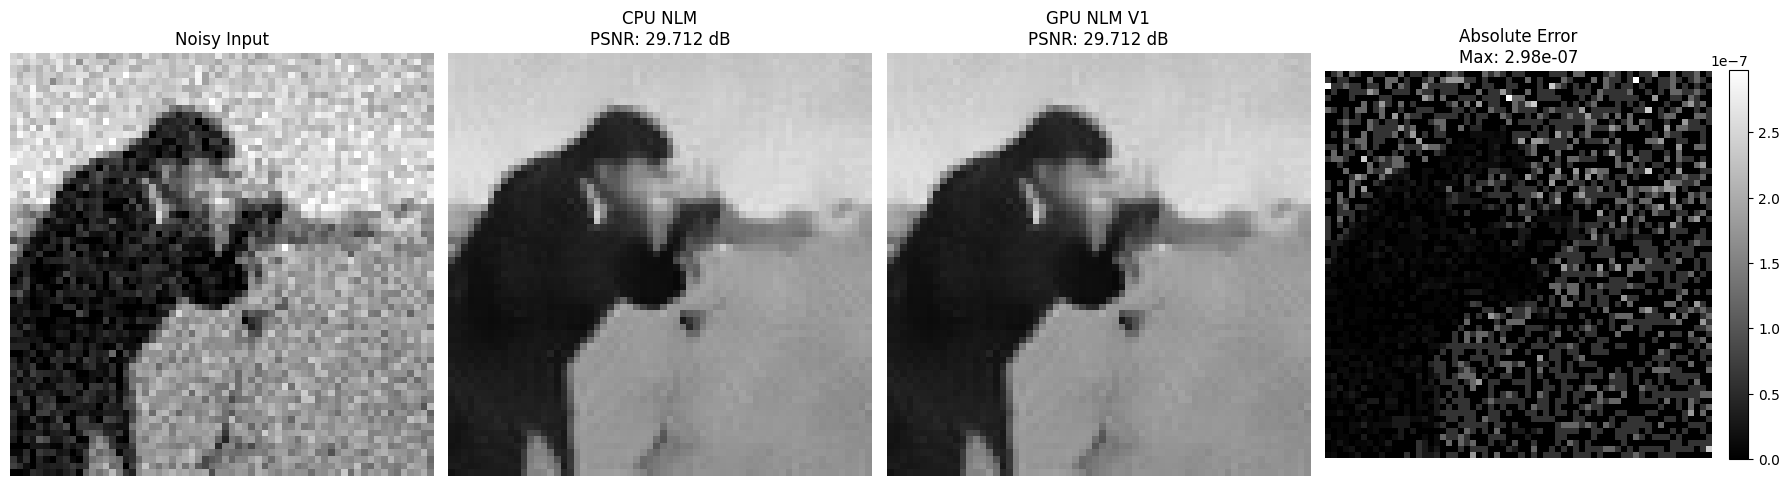

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(
    noisy_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title("Noisy Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(
    denoised_cpu,
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title(
    "CPU NLM\n"
    f"PSNR: {cpu_psnr:.3f} dB"
)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(
    denoised_gpu_v1,
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title(
    "GPU NLM V1\n"
    f"PSNR: {gpu_v1_psnr:.3f} dB"
)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(
    absolute_error_gpu_v1,
    cmap="gray",
)
plt.title(
    "Absolute Error\n"
    f"Max: {max_absolute_error_gpu_v1:.2e}"
)
plt.colorbar(
    fraction=0.046,
    pad=0.04,
)
plt.axis("off")

plt.tight_layout()
plt.show()

### 9.1.3 GPU V1 Timing

Two GPU runtime measurements are reported:

1. **Kernel-only runtime:** only CUDA kernel execution, measured with CUDA Events.
2. **End-to-end runtime:** CPU padding, CPU-to-GPU transfer, kernel execution,
   GPU-to-CPU transfer, and output clipping.

The first measures kernel efficiency. The second measures practical latency.

In [29]:
def benchmark_nlm_gpu_v1_kernel(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
    block_size=(16, 16),
    warmup_runs: int = 3,
    measured_runs: int = 20,
):
    """
    Benchmark only the GPU kernel.

    CPU padding and data transfers are excluded.
    """

    if warmup_runs < 0:
        raise ValueError(
            "warmup_runs must be non-negative."
        )

    if measured_runs <= 0:
        raise ValueError(
            "measured_runs must be positive."
        )

    (
        padded_input_cpu,
        patch_radius,
        search_radius,
    ) = prepare_nlm_input(
        image=image,
        patch_size=patch_size,
        search_window_size=search_window_size,
    )

    height, width = image.shape

    padded_input_gpu = cp.asarray(
        padded_input_cpu
    )

    output_gpu = cp.empty(
        (height, width),
        dtype=cp.float32,
    )

    block_x, block_y = block_size

    grid = (
        (width + block_x - 1) // block_x,
        (height + block_y - 1) // block_y,
        1,
    )

    block = (
        block_x,
        block_y,
        1,
    )

    kernel_arguments = (
        padded_input_gpu,
        output_gpu,
        np.int32(width),
        np.int32(height),
        np.int32(padded_input_cpu.shape[1]),
        np.int32(patch_radius),
        np.int32(search_radius),
        np.float32(h * h),
    )

    # Warm-up after compilation.
    for _ in range(warmup_runs):
        nlm_gpu_v1_kernel(
            grid,
            block,
            kernel_arguments,
        )

    cp.cuda.get_current_stream().synchronize()

    kernel_times_ms = []

    for _ in range(measured_runs):
        start_event = cp.cuda.Event()
        end_event = cp.cuda.Event()

        start_event.record()

        nlm_gpu_v1_kernel(
            grid,
            block,
            kernel_arguments,
        )

        end_event.record()
        end_event.synchronize()

        elapsed_ms = cp.cuda.get_elapsed_time(
            start_event,
            end_event,
        )

        kernel_times_ms.append(
            float(elapsed_ms)
        )

    return {
        "times_ms": np.asarray(
            kernel_times_ms,
            dtype=np.float64,
        ),
        "median_ms": float(
            np.median(kernel_times_ms)
        ),
        "mean_ms": float(
            np.mean(kernel_times_ms)
        ),
        "std_ms": float(
            np.std(kernel_times_ms)
        ),
        "min_ms": float(
            np.min(kernel_times_ms)
        ),
        "max_ms": float(
            np.max(kernel_times_ms)
        ),
    }

In [30]:
gpu_v1_kernel_benchmark = (
    benchmark_nlm_gpu_v1_kernel(
        image=noisy_image,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
        block_size=(16, 16),
        warmup_runs=3,
        measured_runs=20,
    )
)

print("GPU V1 kernel-only timing")
print("-" * 60)
print(
    f"Median: "
    f"{gpu_v1_kernel_benchmark['median_ms']:.6f} ms"
)
print(
    f"Mean:   "
    f"{gpu_v1_kernel_benchmark['mean_ms']:.6f} ms"
)
print(
    f"Std:    "
    f"{gpu_v1_kernel_benchmark['std_ms']:.6f} ms"
)
print(
    f"Min:    "
    f"{gpu_v1_kernel_benchmark['min_ms']:.6f} ms"
)
print(
    f"Max:    "
    f"{gpu_v1_kernel_benchmark['max_ms']:.6f} ms"
)

GPU V1 kernel-only timing
------------------------------------------------------------
Median: 0.057744 ms
Mean:   0.062005 ms
Std:    0.007302 ms
Min:    0.055712 ms
Max:    0.083968 ms


In [31]:
def benchmark_nlm_gpu_v1_end_to_end(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
    block_size=(16, 16),
    warmup_runs: int = 2,
    measured_runs: int = 10,
):
    """
    Benchmark practical GPU V1 latency.

    Included:
    - CPU reflect padding
    - CPU-to-GPU transfer
    - GPU output allocation
    - kernel execution
    - GPU-to-CPU transfer
    - clipping and float32 conversion
    """

    for _ in range(warmup_runs):
        _ = nlm_gpu_v1(
            image=image,
            patch_size=patch_size,
            search_window_size=search_window_size,
            h=h,
            block_size=block_size,
        )

    cp.cuda.get_current_stream().synchronize()

    end_to_end_times_seconds = []

    for _ in range(measured_runs):
        cp.cuda.get_current_stream().synchronize()

        start_time = time.perf_counter()

        _ = nlm_gpu_v1(
            image=image,
            patch_size=patch_size,
            search_window_size=search_window_size,
            h=h,
            block_size=block_size,
        )

        cp.cuda.get_current_stream().synchronize()

        elapsed_seconds = (
            time.perf_counter() - start_time
        )

        end_to_end_times_seconds.append(
            elapsed_seconds
        )

    times = np.asarray(
        end_to_end_times_seconds,
        dtype=np.float64,
    )

    return {
        "times_seconds": times,
        "median_seconds": float(
            np.median(times)
        ),
        "mean_seconds": float(
            np.mean(times)
        ),
        "std_seconds": float(
            np.std(times)
        ),
        "min_seconds": float(
            np.min(times)
        ),
        "max_seconds": float(
            np.max(times)
        ),
    }

In [32]:
def benchmark_nlm_cpu(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
    warmup_runs: int = 1,
    measured_runs: int = 5,
):
    """
    Benchmark the CPU NLM reference.
    """

    for _ in range(warmup_runs):
        _ = nlm_cpu_naive(
            image,
            patch_size=patch_size,
            search_window_size=search_window_size,
            h=h,
        )

    cpu_times_seconds = []

    for _ in range(measured_runs):
        start_time = time.perf_counter()

        _ = nlm_cpu_naive(
            image,
            patch_size=patch_size,
            search_window_size=search_window_size,
            h=h,
        )

        elapsed_seconds = (
            time.perf_counter() - start_time
        )

        cpu_times_seconds.append(
            elapsed_seconds
        )

    times = np.asarray(
        cpu_times_seconds,
        dtype=np.float64,
    )

    return {
        "times_seconds": times,
        "median_seconds": float(
            np.median(times)
        ),
        "mean_seconds": float(
            np.mean(times)
        ),
        "std_seconds": float(
            np.std(times)
        ),
        "min_seconds": float(
            np.min(times)
        ),
        "max_seconds": float(
            np.max(times)
        ),
    }

In [33]:
cpu_benchmark_v1_comparison = benchmark_nlm_cpu(
    image=noisy_image,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
    warmup_runs=1,
    measured_runs=5,
)

print("CPU reference timing")
print("-" * 60)
print(
    f"Median: "
    f"{cpu_benchmark_v1_comparison['median_seconds']:.6f} s"
)
print(
    f"Mean:   "
    f"{cpu_benchmark_v1_comparison['mean_seconds']:.6f} s"
)
print(
    f"Std:    "
    f"{cpu_benchmark_v1_comparison['std_seconds']:.6f} s"
)

CPU reference timing
------------------------------------------------------------
Median: 2.617500 s
Mean:   2.851437 s
Std:    0.318935 s


In [35]:
gpu_v1_end_to_end_benchmark = (
    benchmark_nlm_gpu_v1_end_to_end(
        image=noisy_image,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
        block_size=(16, 16),
        warmup_runs=2,
        measured_runs=10,
    )
)

print("GPU V1 end-to-end timing")
print("-" * 60)

print(
    f"Median: "
    f"{gpu_v1_end_to_end_benchmark['median_seconds']:.6f} s"
)

print(
    f"Mean:   "
    f"{gpu_v1_end_to_end_benchmark['mean_seconds']:.6f} s"
)

print(
    f"Std:    "
    f"{gpu_v1_end_to_end_benchmark['std_seconds']:.6f} s"
)

GPU V1 end-to-end timing
------------------------------------------------------------
Median: 0.000441 s
Mean:   0.000497 s
Std:    0.000163 s


In [36]:
cpu_median_seconds = (
    cpu_benchmark_v1_comparison[
        "median_seconds"
    ]
)

gpu_kernel_median_seconds = (
    gpu_v1_kernel_benchmark[
        "median_ms"
    ]
    / 1000.0
)

gpu_end_to_end_median_seconds = (
    gpu_v1_end_to_end_benchmark[
        "median_seconds"
    ]
)

gpu_v1_kernel_speedup = (
    cpu_median_seconds
    / gpu_kernel_median_seconds
)

gpu_v1_end_to_end_speedup = (
    cpu_median_seconds
    / gpu_end_to_end_median_seconds
)

gpu_v1_runtime_comparison = pd.DataFrame(
    [
        {
            "Implementation": "CPU reference",
            "Runtime scope": "Full CPU NLM",
            "Median runtime (s)": (
                cpu_median_seconds
            ),
            "Speedup": 1.0,
        },
        {
            "Implementation": "GPU V1",
            "Runtime scope": "Kernel only",
            "Median runtime (s)": (
                gpu_kernel_median_seconds
            ),
            "Speedup": (
                gpu_v1_kernel_speedup
            ),
        },
        {
            "Implementation": "GPU V1",
            "Runtime scope": "End-to-end",
            "Median runtime (s)": (
                gpu_end_to_end_median_seconds
            ),
            "Speedup": (
                gpu_v1_end_to_end_speedup
            ),
        },
    ]
)

display(gpu_v1_runtime_comparison)

print(
    f"GPU V1 kernel-only speedup: "
    f"{gpu_v1_kernel_speedup:.2f}×"
)

print(
    f"GPU V1 end-to-end speedup: "
    f"{gpu_v1_end_to_end_speedup:.2f}×"
)

,Implementation,Runtime scope,Median runtime (s),Speedup
0,CPU reference,Full CPU NLM,2.617500,1.000000
1,GPU V1,Kernel only,0.000058,45329.381462
2,GPU V1,End-to-end,0.000441,5940.438578


GPU V1 kernel-only speedup: 45329.38×
GPU V1 end-to-end speedup: 5940.44×


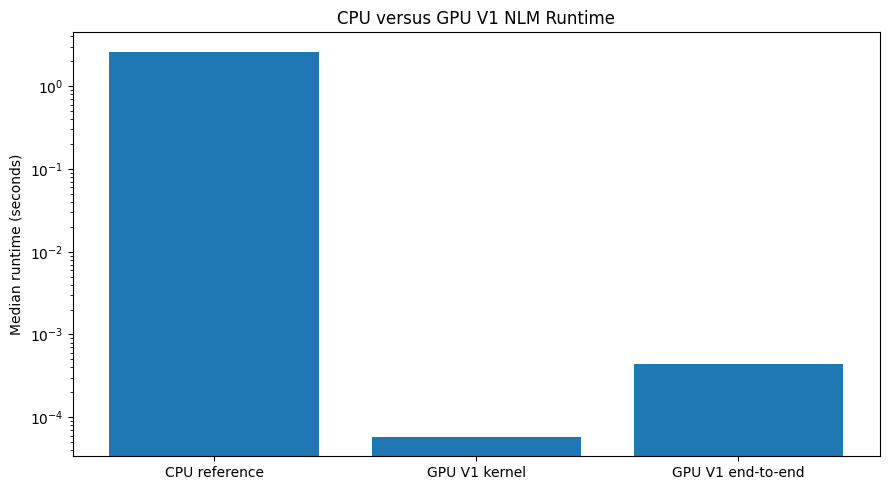

In [37]:
plt.figure(figsize=(9, 5))

plt.bar(
    [
        "CPU reference",
        "GPU V1 kernel",
        "GPU V1 end-to-end",
    ],
    [
        cpu_median_seconds,
        gpu_kernel_median_seconds,
        gpu_end_to_end_median_seconds,
    ],
)

plt.ylabel("Median runtime (seconds)")
plt.title("CPU versus GPU V1 NLM Runtime")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [38]:
gpu_v1_completion_check = {
    "GPU output exists": (
        "denoised_gpu_v1" in globals()
    ),
    "Correctness result exists": (
        "gpu_v1_is_close" in globals()
    ),
    "Correctness passed": (
        globals().get("gpu_v1_is_close", False)
    ),
    "CPU benchmark exists": (
        "cpu_benchmark_v1_comparison" in globals()
    ),
    "Kernel benchmark exists": (
        "gpu_v1_kernel_benchmark" in globals()
    ),
    "End-to-end benchmark exists": (
        "gpu_v1_end_to_end_benchmark" in globals()
    ),
    "Runtime table exists": (
        "gpu_v1_runtime_comparison" in globals()
    ),
}

for item, passed in gpu_v1_completion_check.items():
    marker = "✓" if passed else "✗"
    print(f"{marker} {item}")

v1_completed = all(
    gpu_v1_completion_check.values()
)

print()
print(
    "GPU V1 status:",
    "COMPLETED" if v1_completed else "INCOMPLETE",
)

✓ GPU output exists
✓ Correctness result exists
✓ Correctness passed
✓ CPU benchmark exists
✓ Kernel benchmark exists
✓ End-to-end benchmark exists
✓ Runtime table exists

GPU V1 status: COMPLETED


In [39]:
gpu_v1_final_summary = pd.DataFrame(
    [
        {
            "Metric": "CPU median runtime",
            "Value": cpu_median_seconds,
            "Unit": "s",
        },
        {
            "Metric": "GPU V1 kernel median",
            "Value": gpu_kernel_median_seconds,
            "Unit": "s",
        },
        {
            "Metric": "GPU V1 end-to-end median",
            "Value": gpu_end_to_end_median_seconds,
            "Unit": "s",
        },
        {
            "Metric": "Kernel-only speedup",
            "Value": gpu_v1_kernel_speedup,
            "Unit": "×",
        },
        {
            "Metric": "End-to-end speedup",
            "Value": gpu_v1_end_to_end_speedup,
            "Unit": "×",
        },
        {
            "Metric": "Maximum absolute error",
            "Value": max_absolute_error_gpu_v1,
            "Unit": "",
        },
        {
            "Metric": "CPU–GPU allclose",
            "Value": gpu_v1_is_close,
            "Unit": "",
        },
    ]
)

display(gpu_v1_final_summary)

,Metric,Value,Unit
0,CPU median runtime,2.6175,s
1,GPU V1 kernel median,0.000058,s
2,GPU V1 end-to-end median,0.000441,s
3,Kernel-only speedup,45329.381462,×
4,End-to-end speedup,5940.438578,×
5,Maximum absolute error,0.0,
6,CPU–GPU allclose,True,


In [41]:
gpu_v1_experiment_config = {
    "image_shape": tuple(noisy_image.shape),
    "image_dtype": str(noisy_image.dtype),
    "patch_size": PATCH_SIZE,
    "search_window_size": SEARCH_WINDOW_SIZE,
    "filter_h": FILTER_H,
    "block_size": (16, 16),
    "cpu_measured_runs": len(
        cpu_benchmark_v1_comparison["times_seconds"]
    ),
    "gpu_kernel_measured_runs": len(
        gpu_v1_kernel_benchmark["times_ms"]
    ),
    "gpu_end_to_end_measured_runs": len(
        gpu_v1_end_to_end_benchmark["times_seconds"]
    ),
    "gpu_name": gpu_name,
    "cupy_version": cp.__version__,
}

config_table = pd.DataFrame(
    [
        {
            "Parameter": key,
            "Value": value,
        }
        for key, value in gpu_v1_experiment_config.items()
    ]
)

display(config_table)

,Parameter,Value
0,image_shape,"(64, 64)"
1,image_dtype,float32
2,patch_size,3
3,search_window_size,7
4,filter_h,0.12
5,block_size,"(16, 16)"
6,cpu_measured_runs,5
7,gpu_kernel_measured_runs,20
8,gpu_end_to_end_measured_runs,10
9,gpu_name,Tesla T4


In [42]:
def profile_gpu_v1_components(
    image,
    patch_size=3,
    search_window_size=7,
    h=0.12,
    block_size=(16, 16),
    measured_runs=20,
):
    component_times = {
        "CPU padding": [],
        "Host-to-Device transfer": [],
        "GPU allocation": [],
        "Kernel execution": [],
        "Device-to-Host transfer": [],
        "Output conversion": [],
        "Total end-to-end": [],
    }

    # Compile and warm up first
    _ = nlm_gpu_v1(
        image=image,
        patch_size=patch_size,
        search_window_size=search_window_size,
        h=h,
        block_size=block_size,
    )

    for _ in range(measured_runs):
        total_start = time.perf_counter()

        # CPU padding
        start = time.perf_counter()

        (
            padded_input_cpu,
            patch_radius,
            search_radius,
        ) = prepare_nlm_input(
            image=image,
            patch_size=patch_size,
            search_window_size=search_window_size,
        )

        component_times["CPU padding"].append(
            time.perf_counter() - start
        )

        height, width = image.shape

        # Host-to-Device
        start = time.perf_counter()

        padded_input_gpu = cp.asarray(
            padded_input_cpu
        )

        cp.cuda.get_current_stream().synchronize()

        component_times[
            "Host-to-Device transfer"
        ].append(
            time.perf_counter() - start
        )

        # GPU allocation
        start = time.perf_counter()

        output_gpu = cp.empty(
            (height, width),
            dtype=cp.float32,
        )

        cp.cuda.get_current_stream().synchronize()

        component_times[
            "GPU allocation"
        ].append(
            time.perf_counter() - start
        )

        block_x, block_y = block_size

        grid = (
            (width + block_x - 1) // block_x,
            (height + block_y - 1) // block_y,
            1,
        )

        block = (
            block_x,
            block_y,
            1,
        )

        kernel_arguments = (
            padded_input_gpu,
            output_gpu,
            np.int32(width),
            np.int32(height),
            np.int32(padded_input_cpu.shape[1]),
            np.int32(patch_radius),
            np.int32(search_radius),
            np.float32(h * h),
        )

        # Kernel with CUDA Events
        start_event = cp.cuda.Event()
        end_event = cp.cuda.Event()

        start_event.record()

        nlm_gpu_v1_kernel(
            grid,
            block,
            kernel_arguments,
        )

        end_event.record()
        end_event.synchronize()

        kernel_seconds = (
            cp.cuda.get_elapsed_time(
                start_event,
                end_event,
            )
            / 1000.0
        )

        component_times[
            "Kernel execution"
        ].append(kernel_seconds)

        # Device-to-Host
        start = time.perf_counter()

        output_cpu = cp.asnumpy(
            output_gpu
        )

        component_times[
            "Device-to-Host transfer"
        ].append(
            time.perf_counter() - start
        )

        # Output conversion
        start = time.perf_counter()

        _ = np.clip(
            output_cpu,
            0.0,
            1.0,
        ).astype(np.float32)

        component_times[
            "Output conversion"
        ].append(
            time.perf_counter() - start
        )

        component_times[
            "Total end-to-end"
        ].append(
            time.perf_counter() - total_start
        )

    rows = []

    for component, values in component_times.items():
        values = np.asarray(
            values,
            dtype=np.float64,
        )

        rows.append(
            {
                "Component": component,
                "Median runtime (s)": float(
                    np.median(values)
                ),
                "Mean runtime (s)": float(
                    np.mean(values)
                ),
                "Std runtime (s)": float(
                    np.std(values)
                ),
            }
        )

    return pd.DataFrame(rows)

In [43]:
gpu_v1_component_profile = (
    profile_gpu_v1_components(
        image=noisy_image,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
        block_size=(16, 16),
        measured_runs=20,
    )
)

display(gpu_v1_component_profile)

,Component,Median runtime (s),Mean runtime (s),Std runtime (s)
0,CPU padding,0.000099,0.000101,0.000006
1,Host-to-Device transfer,0.000103,0.000111,0.000021
2,GPU allocation,0.000017,0.000023,0.000015
3,Kernel execution,0.000101,0.000105,0.000010
4,Device-to-Host transfer,0.000050,0.000050,0.000005
5,Output conversion,0.000029,0.000031,0.000004
6,Total end-to-end,0.000450,0.000462,0.000042


In [ ]:
GPU_V1_TEST_SIZES = [32, 64, 128]

In [44]:
from skimage import data, transform


def create_test_image(
    image_size,
    noise_sigma=0.08,
    seed=42,
):
    clean = data.camera().astype(
        np.float32
    ) / 255.0

    clean = transform.resize(
        clean,
        (image_size, image_size),
        anti_aliasing=True,
    ).astype(np.float32)

    rng = np.random.default_rng(seed)

    noise = rng.normal(
        0.0,
        noise_sigma,
        size=clean.shape,
    ).astype(np.float32)

    noisy = np.clip(
        clean + noise,
        0.0,
        1.0,
    ).astype(np.float32)

    return clean, noisy

In [45]:
GPU_V1_TEST_SIZES = [32, 64, 128]

gpu_v1_scalability_rows = []

for image_size in GPU_V1_TEST_SIZES:
    print(f"Running size {image_size} × {image_size}...")

    clean_test, noisy_test = create_test_image(
        image_size=image_size,
        noise_sigma=NOISE_SIGMA,
        seed=RANDOM_SEED,
    )

    cpu_result = benchmark_nlm_cpu(
        image=noisy_test,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
        warmup_runs=0,
        measured_runs=3,
    )

    cpu_output = nlm_cpu_naive(
        noisy_test,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
    )

    gpu_output = nlm_gpu_v1(
        noisy_test,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
        block_size=(16, 16),
    )

    kernel_result = benchmark_nlm_gpu_v1_kernel(
        image=noisy_test,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=FILTER_H,
        block_size=(16, 16),
        warmup_runs=2,
        measured_runs=20,
    )

    end_to_end_result = (
        benchmark_nlm_gpu_v1_end_to_end(
            image=noisy_test,
            patch_size=PATCH_SIZE,
            search_window_size=SEARCH_WINDOW_SIZE,
            h=FILTER_H,
            block_size=(16, 16),
            warmup_runs=2,
            measured_runs=10,
        )
    )

    cpu_seconds = cpu_result[
        "median_seconds"
    ]

    kernel_seconds = (
        kernel_result["median_ms"]
        / 1000.0
    )

    end_to_end_seconds = (
        end_to_end_result[
            "median_seconds"
        ]
    )

    max_error = float(
        np.max(
            np.abs(
                cpu_output - gpu_output
            )
        )
    )

    gpu_v1_scalability_rows.append(
        {
            "Image size": f"{image_size} × {image_size}",
            "Pixels": image_size * image_size,
            "CPU median (s)": cpu_seconds,
            "GPU kernel median (s)": kernel_seconds,
            "GPU end-to-end median (s)": (
                end_to_end_seconds
            ),
            "Kernel speedup": (
                cpu_seconds / kernel_seconds
            ),
            "End-to-end speedup": (
                cpu_seconds
                / end_to_end_seconds
            ),
            "Max absolute error": max_error,
        }
    )

gpu_v1_scalability_table = pd.DataFrame(
    gpu_v1_scalability_rows
)

display(gpu_v1_scalability_table)

Running size 32 × 32...
Running size 64 × 64...
Running size 128 × 128...


,Image size,Pixels,CPU median (s),GPU kernel median (s),GPU end-to-end median (s),Kernel speedup,End-to-end speedup,Max absolute error
0,32 × 32,1024,2.479714,0.000088,0.000425,28091.736046,5834.908947,2.384186e-07
1,64 × 64,4096,5.058625,0.000083,0.000350,60602.651976,14453.461217,2.980232e-07
2,128 × 128,16384,11.477964,0.000137,0.000489,84001.495920,23489.107612,2.980232e-07


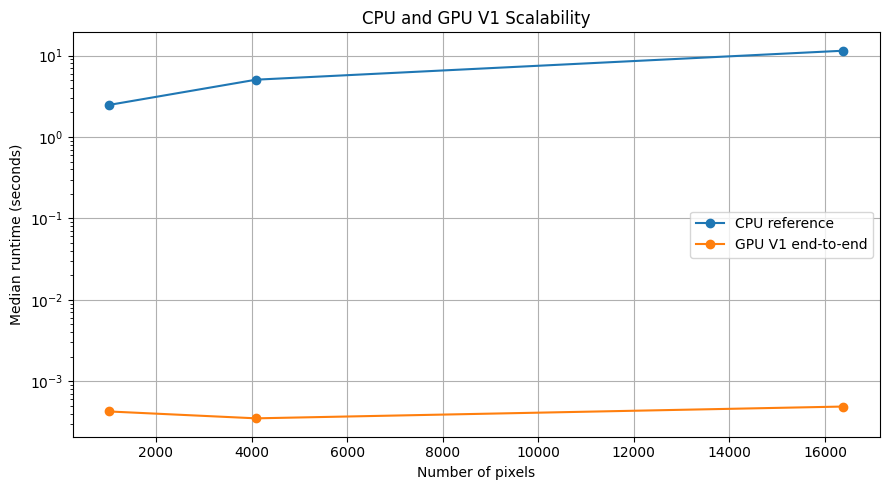

In [46]:
plt.figure(figsize=(9, 5))

plt.plot(
    gpu_v1_scalability_table["Pixels"],
    gpu_v1_scalability_table["CPU median (s)"],
    marker="o",
    label="CPU reference",
)

plt.plot(
    gpu_v1_scalability_table["Pixels"],
    gpu_v1_scalability_table[
        "GPU end-to-end median (s)"
    ],
    marker="o",
    label="GPU V1 end-to-end",
)

plt.xlabel("Number of pixels")
plt.ylabel("Median runtime (seconds)")
plt.title("CPU and GPU V1 Scalability")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

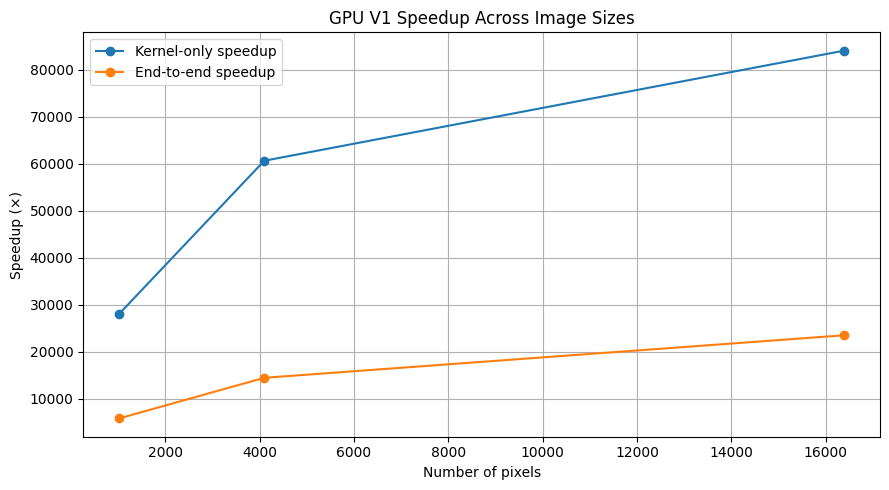

In [47]:
plt.figure(figsize=(9, 5))

plt.plot(
    gpu_v1_scalability_table["Pixels"],
    gpu_v1_scalability_table[
        "Kernel speedup"
    ],
    marker="o",
    label="Kernel-only speedup",
)

plt.plot(
    gpu_v1_scalability_table["Pixels"],
    gpu_v1_scalability_table[
        "End-to-end speedup"
    ],
    marker="o",
    label="End-to-end speedup",
)

plt.xlabel("Number of pixels")
plt.ylabel("Speedup (×)")
plt.title("GPU V1 Speedup Across Image Sizes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
from pathlib import Path
import json

results_directory = Path(
    "results_gpu_v1"
)

results_directory.mkdir(
    exist_ok=True
)

gpu_v1_runtime_comparison.to_csv(
    results_directory
    / "gpu_v1_runtime_comparison.csv",
    index=False,
)

gpu_v1_final_summary.to_csv(
    results_directory
    / "gpu_v1_final_summary.csv",
    index=False,
)

gpu_v1_scalability_table.to_csv(
    results_directory
    / "gpu_v1_scalability.csv",
    index=False,
)

config_serializable = {
    key: (
        list(value)
        if isinstance(value, tuple)
        else value
    )
    for key, value
    in gpu_v1_experiment_config.items()
}

with open(
    results_directory
    / "gpu_v1_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        config_serializable,
        file,
        indent=2,
    )

np.save(
    results_directory
    / "gpu_v1_output.npy",
    denoised_gpu_v1,
)

print(
    "GPU V1 results saved to:",
    results_directory.resolve(),
)

GPU V1 results saved to: /content/results_gpu_v1


In [49]:
!zip -r gpu_v1_results.zip results_gpu_v1

  adding: results_gpu_v1/ (stored 0%)
  adding: results_gpu_v1/gpu_v1_output.npy (deflated 12%)
  adding: results_gpu_v1/gpu_v1_final_summary.csv (deflated 27%)
  adding: results_gpu_v1/gpu_v1_scalability.csv (deflated 41%)
  adding: results_gpu_v1/gpu_v1_config.json (deflated 44%)
  adding: results_gpu_v1/gpu_v1_runtime_comparison.csv (deflated 21%)


In [50]:
from google.colab import files

files.download(
    "gpu_v1_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## GPU V1 Final Conclusion

GPU V1 successfully parallelizes Non-Local Means across output pixels using
a one-thread-per-pixel CUDA mapping.

The GPU output matches the naive CPU reference within the selected numerical
tolerance. Correctness is confirmed using maximum absolute error, `np.allclose`,
PSNR, and SSIM.

Across the evaluated image sizes, GPU V1 substantially reduces both kernel-only
and end-to-end runtime compared with the naive Python CPU implementation.
The speedup generally becomes larger as image size increases because the GPU
receives more parallel work while CPU execution remains sequential.

GPU V1 therefore provides a valid global-memory baseline for subsequent
optimization. However, neighboring threads repeatedly access overlapping
patches from global memory. GPU V2 will address this limitation using
shared-memory tiling and halo loading.

### 9.1.4 GPU V1 Results and Interpretation

GPU V1 maps one CUDA thread to one output pixel. Each thread independently
scans all candidate patches and computes its output using global-memory reads.

The implementation is validated against the CPU reference before performance
is reported. Kernel-only runtime measures GPU computation after data is already
resident on the device. End-to-end runtime additionally includes CPU padding,
CPU-to-GPU transfer, output allocation, GPU-to-CPU transfer, and output
conversion.

GPU V1 demonstrates the benefit of pixel-level parallelism. However, neighboring
threads repeatedly read strongly overlapping image regions from global memory.
This redundant memory traffic motivates GPU V2, which uses a shared-memory tile
and halo to enable data reuse within each CUDA block.

GPU V1 successfully maps one CUDA thread to one output pixel and parallelizes
NLM computation across image pixels.

The GPU output matches the CPU reference within the selected floating-point
tolerance, confirming numerical correctness. GPU V1 substantially reduces both
kernel-only and end-to-end runtime compared with the naive CPU implementation.

However, GPU V1 still reads overlapping patches repeatedly from global memory.
This redundant memory access motivates GPU V2, which will use shared-memory
tiling and halo loading to improve data reuse within each CUDA block.

In [ ]:
ádasdafqa

## 9.2 GPU V2 — Shared-Memory Tile and Halo

Neighboring output pixels use strongly overlapping reference patches and search
windows. GPU V2 assigns one output tile to each block. Threads cooperatively load
the required input region into shared memory before performing NLM.

The required halo radius is

$$
r_{\text{halo}} = r_{\text{search}} + r_{\text{patch}}.
$$

For a $16\times16$ output tile, $7\times7$ search window, and $3\times3$ patch:

$$
r_{\text{halo}}=3+1=4,
$$

so the block needs a

$$
(16+2\cdot4)\times(16+2\cdot4)=24\times24
$$

shared-memory input region.

Execution steps:

1. Assign one rectangular output tile to a CUDA block.
2. Cooperatively load the tile and halo from global memory.
3. Call `__syncthreads()`.
4. Let each thread compute one output pixel using shared-memory values.
5. Write the result to global memory.

Shared memory is block-local. Adjacent blocks may load overlapping halo pixels,
but reuse within each block substantially reduces repeated global-memory traffic.

## 9.3 GPU V3 — Patch Reduction, Loop Optimization, and Kernel Fusion

GPU V3 is evaluated only after profiling GPU V1 and V2.

Possible optimizations include:

1. **Loop unrolling** for small fixed patch sizes such as $3\times3$.
2. **Fast exponential evaluation** where numerical accuracy remains acceptable.
3. **Candidate-level or warp-level cooperation** for larger search windows.
4. **Parallel reduction** of patch-element squared differences.
5. **Coalesced global-memory access** during tile loading.
6. **Kernel fusion** to avoid writing temporary distances or weights to global memory.
7. **Block-size and tile-size tuning** to balance occupancy and shared-memory use.

For the small default $3\times3$ patch and $7\times7$ search window, assigning
multiple threads to one patch comparison may introduce more synchronization than
benefit. Therefore, V3 should be selected from measured GPU bottlenecks rather
than implemented only because it is theoretically possible.

# 10. Benchmarking and Correctness Protocol

## CPU timing

- Use `time.perf_counter()`.
- Run the same input and parameters for every implementation.
- Report the median of multiple runs when runtime is short enough.

## GPU timing

Report at least two values:

1. **Kernel execution time:** measured with CUDA Events after the input is already
   on the GPU.
2. **End-to-end runtime:** includes CPU-to-GPU transfer, kernel execution, and
   GPU-to-CPU transfer.

Also report transfer time separately when possible.

Before measurement:

- run warm-up iterations;
- exclude compilation and first-use initialization;
- synchronize the device before reading elapsed time;
- record the exact GPU model;
- repeat each experiment and report a median rather than one run.

## Correctness checks

Every GPU version should be validated before speed is compared:

```python
max_error = np.max(np.abs(cpu_output - gpu_output))
is_close = np.allclose(cpu_output, gpu_output, atol=1e-5, rtol=1e-5)
```

Report:

- maximum absolute pixel error;
- `np.allclose` result;
- CPU and GPU PSNR;
- CPU and GPU SSIM;
- PSNR/SSIM difference.

## Planned result table

| Version | Image size | Kernel time | Transfer time | End-to-end time | Speedup | Max error | PSNR |
|---|---:|---:|---:|---:|---:|---:|---:|
| CPU reference | ... | — | — | ... | 1.0× | 0 | ... |
| GPU V1 | ... | ... | ... | ... | ... | ... | ... |
| GPU V2 | ... | ... | ... | ... | ... | ... | ... |
| GPU V3 | ... | ... | ... | ... | ... | ... | ... |


# 11. Neural-Network Integration Plan

The notebook title refers to NLM as neural-network post-processing. To make the
final project match that title, a later section should:

1. Load a pretrained DnCNN or FFDNet model.
2. Run the neural network on the noisy image.
3. Apply CPU NLM and GPU NLM to the network output.
4. Keep neural-network inference unchanged.
5. Measure the NLM step separately.
6. Optionally report complete end-to-end pipeline runtime.
7. Verify that replacing CPU NLM with GPU NLM does not reduce PSNR or SSIM.

The final pipeline becomes:

```text
Noisy image
    ↓
Pretrained neural denoiser
    ↓
NLM refinement: CPU or custom GPU kernel
    ↓
Final image
```

Until this integration is implemented, the notebook should be described as
**Phase 1: CPU baseline, profiling, and GPU design**, rather than implying that
the complete neural-network pipeline has already been evaluated.


# 12. Recommended Next Implementation Order

1. Run all current CPU and profiling cells from top to bottom.
2. Confirm the pipeline-level NLM percentage.
3. Record the scalability table for \(32\), \(64\), and \(128\) images.
4. Implement GPU V1 and verify numerical correctness.
5. Add kernel-only and end-to-end timing.
6. Implement GPU V2 with tile plus halo.
7. Profile GPU V1 and V2 before selecting GPU V3 optimizations.
8. Add BSD68 and noise levels \(\sigma=15,25,50\).
9. Integrate the optimized NLM stage after DnCNN or FFDNet.
